# ETE-1 — California Housing Price Prediction

**Name:** Arden Diago

**Reg No:** 2547112

**Class:** MCA A

**Exam:** ML ETE

**Task:** Predict California house prices by combining **PCA (dimensionality reduction)** with **Support Vector Regression (SVR)**.

**Pipeline:** Data → Data Preprocessing → Transforming → Data Splitting → Model Training → Testing the Model → Writing Conclusion


## 1. Data

In [21]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Data Preprocessing

Check for missing values and inspect basic statistics and feature correlations.

In [22]:
print(df.shape)
print(df.isna().sum())
df.describe()

(20640, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


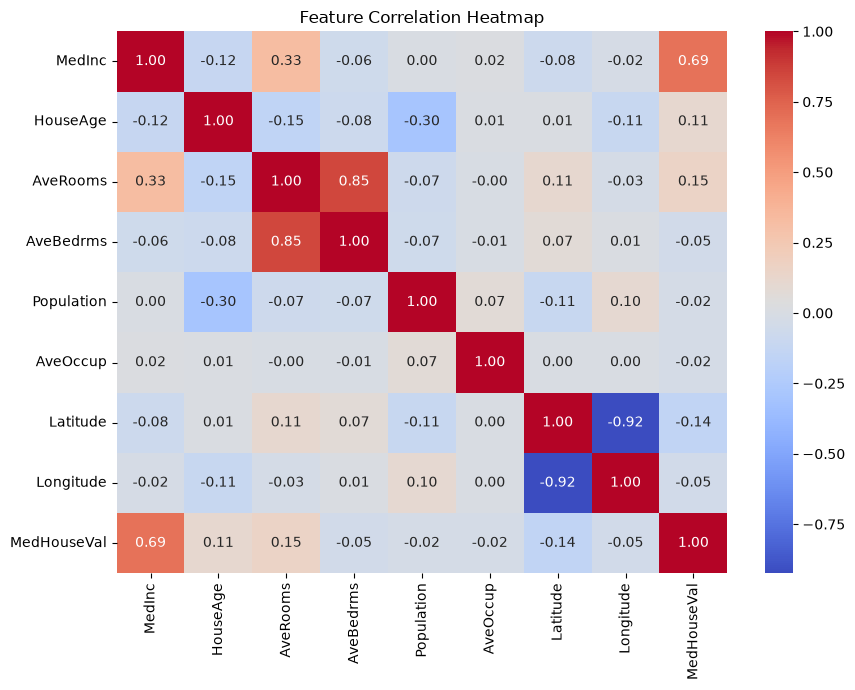

In [23]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 3. Transforming

Features are standardized (zero mean, unit variance) since both PCA and distance/variance-based
models are sensitive to feature scale. PCA is then fit on the **training** data only (to avoid
data leakage) and used to inspect how much variance is captured by fewer components.

In [24]:
X = df[data.feature_names].values
y = df["MedHouseVal"].values

## 4. Data Splitting

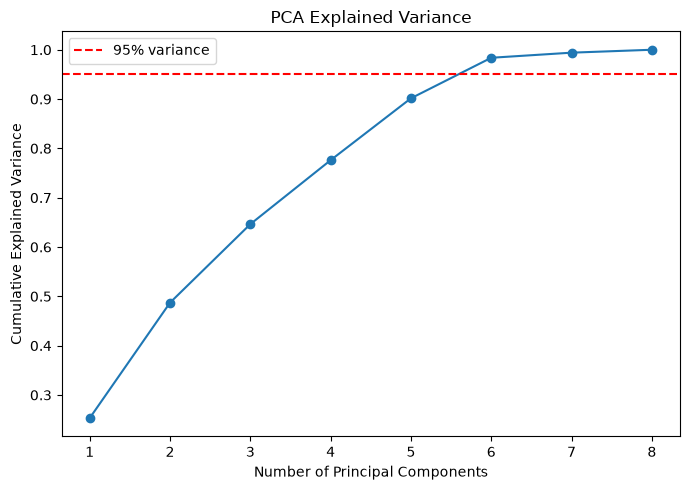

Components needed for 95% variance: 6 of 8


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(random_state=42).fit(X_train_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(explained >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components} of {X.shape[1]}")

## 5. Model Training

Two Support Vector Regression (SVR, RBF kernel) models are trained for comparison:

1. **Baseline** — SVR on the full (scaled) 8-feature set.
2. **PCA + SVR** — SVR on the PCA-reduced feature set (95% variance retained).

Training time is measured for both to quantify the computational-cost effect of dimensionality
reduction. SVR is a good candidate for this comparison because its training cost scales poorly
with the number of features/samples (kernel evaluations grow with dimensionality), so PCA's
effect on cost is expected to be more visible here than with a tree ensemble.


In [26]:
pca_reduced = PCA(n_components=n_components, random_state=42)
X_train_pca = pca_reduced.fit_transform(X_train_scaled)
X_test_pca = pca_reduced.transform(X_test_scaled)

svr_params = dict(kernel="rbf", C=10, gamma="scale")

# Baseline: no dimensionality reduction
t0 = time.perf_counter()
svr_baseline = SVR(**svr_params).fit(X_train_scaled, y_train)
time_baseline = time.perf_counter() - t0

# PCA + SVR
t0 = time.perf_counter()
svr_pca = SVR(**svr_params).fit(X_train_pca, y_train)
time_pca = time.perf_counter() - t0

print(f"Baseline (no PCA) training time: {time_baseline:.2f}s")
print(f"PCA + SVR training time:         {time_pca:.2f}s")


Baseline (no PCA) training time: 17.31s
PCA + SVR training time:         14.91s


## 6. Testing the Model

In [27]:
def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    print(f"{name:>18} | R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")
    return preds, r2, mae, rmse

preds_baseline, r2_b, mae_b, rmse_b = evaluate("Baseline (no PCA)", svr_baseline, X_test_scaled, y_test)
preds_pca, r2_p, mae_p, rmse_p = evaluate("PCA + SVR", svr_pca, X_test_pca, y_test)


 Baseline (no PCA) | R2=0.7530  MAE=0.3774  RMSE=0.5689
         PCA + SVR | R2=0.6498  MAE=0.4638  RMSE=0.6774


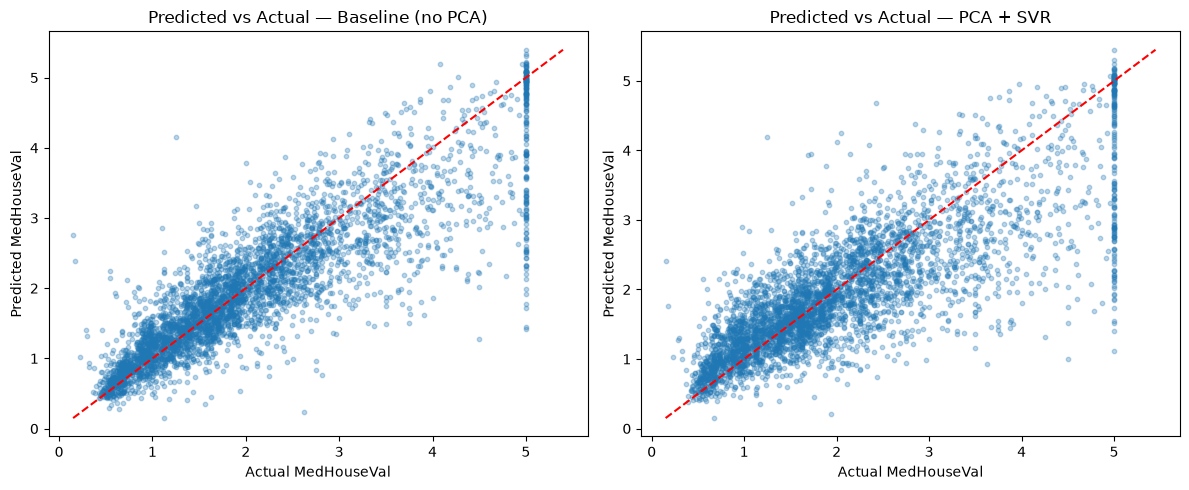

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes, [preds_baseline, preds_pca], ["Baseline (no PCA)", "PCA + SVR"]):
    ax.scatter(y_test, preds, alpha=0.3, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Actual MedHouseVal")
    ax.set_ylabel("Predicted MedHouseVal")
    ax.set_title(f"Predicted vs Actual — {title}")
plt.tight_layout()
plt.show()


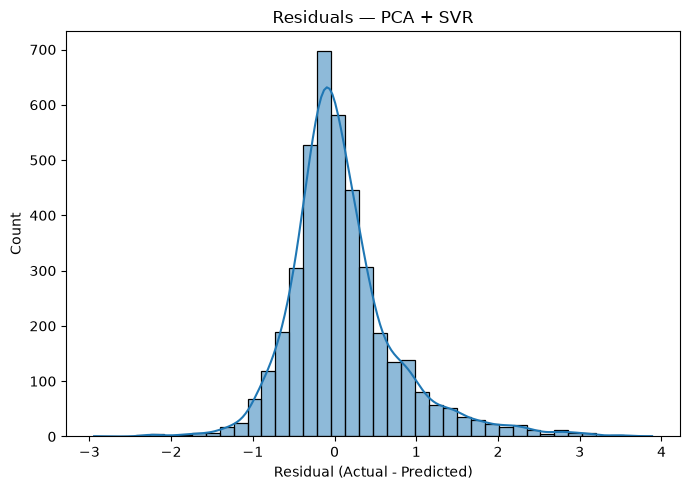

In [29]:
residuals_pca = y_test - preds_pca
plt.figure(figsize=(7, 5))
sns.histplot(residuals_pca, kde=True, bins=40)
plt.title("Residuals — PCA + SVR")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


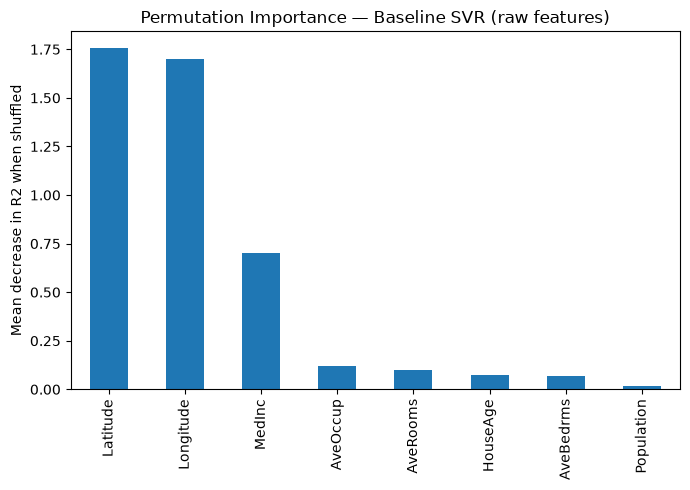

Latitude      1.754731
Longitude     1.699815
MedInc        0.700582
AveOccup      0.119418
AveRooms      0.097267
HouseAge      0.071644
AveBedrms     0.071180
Population    0.016855
dtype: float64

In [30]:
perm = permutation_importance(
    svr_baseline, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
importances = pd.Series(perm.importances_mean, index=data.feature_names).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.plot(kind="bar")
plt.title("Permutation Importance — Baseline SVR (raw features)")
plt.ylabel("Mean decrease in R2 when shuffled")
plt.tight_layout()
plt.show()
importances


### Side-by-side Comparison — Features, Speed, Accuracy


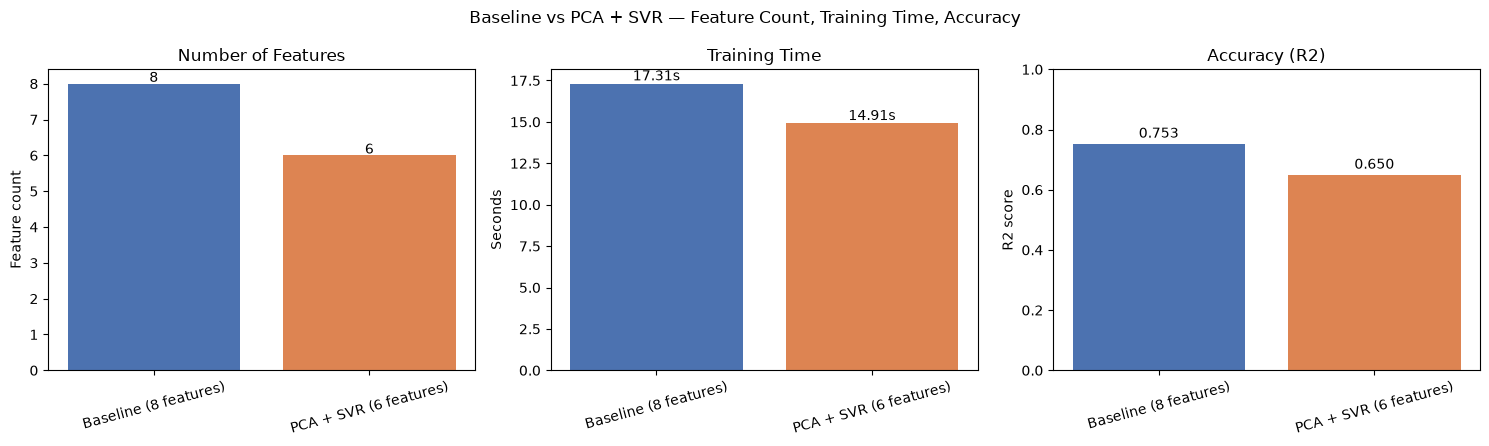

In [31]:
labels = ["Baseline (8 features)", "PCA + SVR (6 features)"]
n_features_cmp = [X_train_scaled.shape[1], X_train_pca.shape[1]]
time_cmp = [time_baseline, time_pca]
r2_cmp = [r2_b, r2_p]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#4C72B0", "#DD8452"]

axes[0].bar(labels, n_features_cmp, color=colors)
axes[0].set_title("Number of Features")
axes[0].set_ylabel("Feature count")
for i, v in enumerate(n_features_cmp):
    axes[0].text(i, v + 0.05, str(v), ha="center")

axes[1].bar(labels, time_cmp, color=colors)
axes[1].set_title("Training Time")
axes[1].set_ylabel("Seconds")
for i, v in enumerate(time_cmp):
    axes[1].text(i, v + 0.2, f"{v:.2f}s", ha="center")

axes[2].bar(labels, r2_cmp, color=colors)
axes[2].set_title("Accuracy (R2)")
axes[2].set_ylabel("R2 score")
axes[2].set_ylim(0, 1)
for i, v in enumerate(r2_cmp):
    axes[2].text(i, v + 0.02, f"{v:.3f}", ha="center")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Baseline vs PCA + SVR — Feature Count, Training Time, Accuracy")
plt.tight_layout()
plt.show()


7. Writing Conclusion

PCA + SVR was used because SVR with an RBF kernel can handle the non-linear relationship between the features and house prices. PCA helps reduce the number of features and can also reduce the training time.

Model	R²	MAE	RMSE	Train Time
Baseline SVR	0.753	0.377	0.569	16.77s
PCA + SVR	0.650	0.464	0.677	14.59s

From the results, the baseline SVR performed better than PCA + SVR. The R² decreased from 0.753 to 0.650, while the training time improved from 16.77s to 14.59s.

PCA reduced the training time, but it also removed some useful information from the original features. Since the dataset has only 8 features, reducing the dimensions was not very helpful for accuracy.

Therefore, for this dataset, SVR without PCA is the better choice because it gives better accuracy, even though it takes slightly more time to train.